In [24]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv('../data/BrentOilPrices.csv')

In [19]:
df.head()

,Price
Date,
1987-05-20,18.63
1987-05-21,18.45
1987-05-22,18.55
1987-05-25,18.60
1987-05-26,18.63


In [5]:
df.columns

Index(['Date', 'Price'], dtype='str')

In [6]:
df.dtypes

Date         str
Price    float64
dtype: object

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9011 entries, 0 to 9010
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    9011 non-null   datetime64[us]
 1   Price   9011 non-null   float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 140.9 KB


In [10]:
df["Date"] = pd.to_datetime(df["Date"], format="%d-%b-%y")

In [12]:
df.isnull().sum()

Date     0
Price    0
dtype: int64

In [16]:
df.describe()

,Price
count,9011.000000
mean,48.420782
std,32.860110
min,9.100000
25%,19.050000
50%,38.570000
75%,70.090000
max,143.950000


In [14]:
df.set_index("Date", inplace=True)

In [17]:
df= df.sort_index()

In [22]:
df.index.duplicated().sum()

np.int64(0)

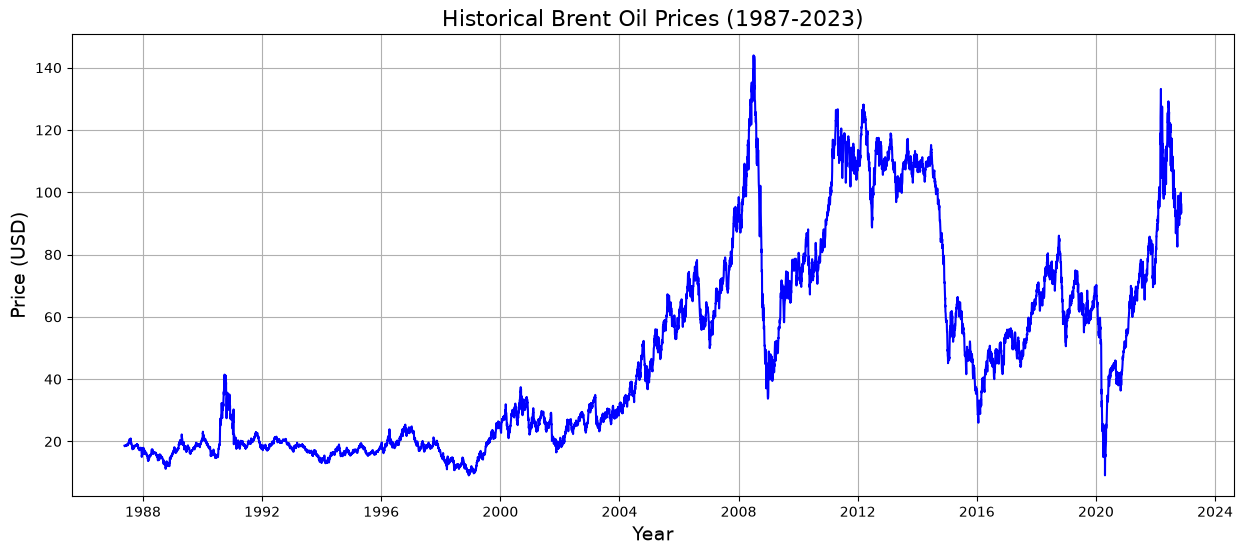

In [25]:
plt.figure(figsize=(15,6))

plt.plot(df.index, df['Price'], color='blue', label='Brent Oil Price')  

plt.title("Historical Brent Oil Prices (1987-2023)", fontsize=16)

plt.xlabel("Year", fontsize=14)

plt.ylabel("Price (USD)", fontsize=14)

plt.grid(True)

plt.show()

### Observation: Historical Brent Oil Prices

The Brent oil price series exhibits significant fluctuations over the study period (1987–2022), indicating that the market is highly dynamic. Several periods of rapid price increases and sharp declines are visible, suggesting the influence of major geopolitical and economic events.

Notable patterns include:

- Relatively stable prices between 1987 and the late 1990s.
- A sustained upward trend from approximately 2003 to 2008.
- A sharp price collapse during the 2008 global financial crisis.
- Another major decline around 2014–2016, coinciding with increased global oil supply.
- An unprecedented drop in 2020 during the COVID-19 pandemic.
- Strong recovery during 2021–2022 following economic reopening and geopolitical tensions.

These visible shifts suggest the presence of structural breaks, making change point detection an appropriate modeling approach.

C:\Users\mijuu\AppData\Local\Temp\ipykernel_27872\2444387729.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Price"], vert=False)


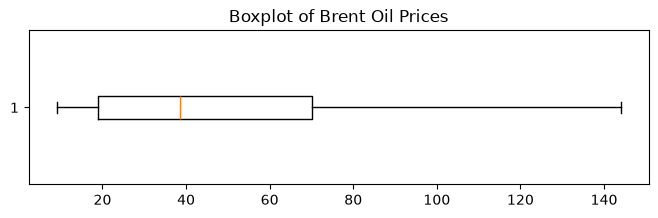

In [28]:
plt.figure(figsize=(8,2))

plt.boxplot(df["Price"], vert=False)

plt.title("Boxplot of Brent Oil Prices")

plt.show()

### Observation: Boxplot

The boxplot shows that Brent oil prices have a wide range of values over the study period. The median price is approximately 40 USD per barrel, while the middle 50% of observations lie roughly between 20 and 70 USD.

The long upper whisker indicates that exceptionally high prices occurred during certain periods, reflecting major market disruptions. Although no extreme statistical outliers are displayed, the large spread confirms substantial variability in oil prices over time.

In [29]:
df["Log_Return"] = np.log(df["Price"]).diff()

In [30]:
df = df.dropna()

In [31]:
df.head()

,Price,Log_Return
Date,,
1987-05-21,18.45,-0.009709
1987-05-22,18.55,0.005405
1987-05-25,18.60,0.002692
1987-05-26,18.63,0.001612
1987-05-27,18.60,-0.001612


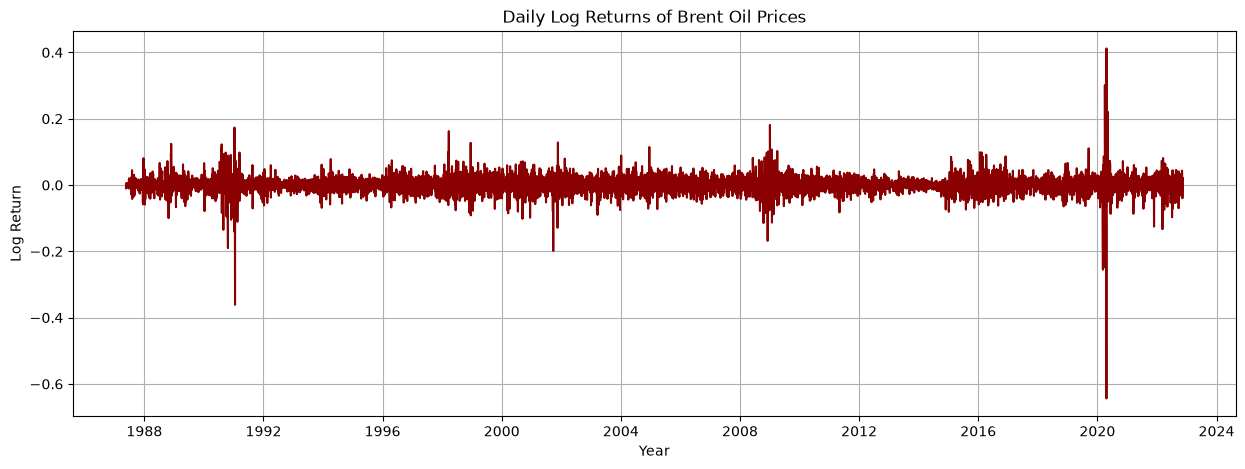

In [32]:
plt.figure(figsize=(15,5))

plt.plot(df.index, df["Log_Return"], color="darkred")

plt.title("Daily Log Returns of Brent Oil Prices")
plt.xlabel("Year")
plt.ylabel("Log Return")

plt.grid(True)

plt.show()